# Outlier Detection using Isolation Forest

## Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

In [2]:
PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_PATH = DATA_DIR / "raw" / "bank-additional-full.csv"
PROCESSED_DATA_PATH = DATA_DIR / "processed" / "bank_marketing_preprocessed.csv"

PROCESSED_DATA_PATH

PosixPath('/Users/janmeet/Desktop/SFU/FALL 2025/CMPT 459/Project/fall2025_cmpt459_d1_group7/data/processed/bank_marketing_preprocessed.csv')

## Load Data

In [3]:
df = pd.read_csv(PROCESSED_DATA_PATH, sep=',')
target_col = "y"
y = df[target_col]
X_df = df.drop(columns=[target_col])


## Isolation Forest

In [12]:
iso = IsolationForest(contamination=0.05, random_state=42)
labels = iso.fit_predict(X_df)
print(labels)

[1 1 1 ... 1 1 1]


In [13]:
n_outliers = (labels == -1).sum()
n_inliers = (labels == 1).sum()

print("Outliers detected:", n_outliers)
print("Inliers:", n_inliers)
print("Outlier percentage:", n_outliers / len(labels) * 100)


Outliers detected: 2060
Inliers: 39128
Outlier percentage: 5.0014567349713515


## Visualize Outliers

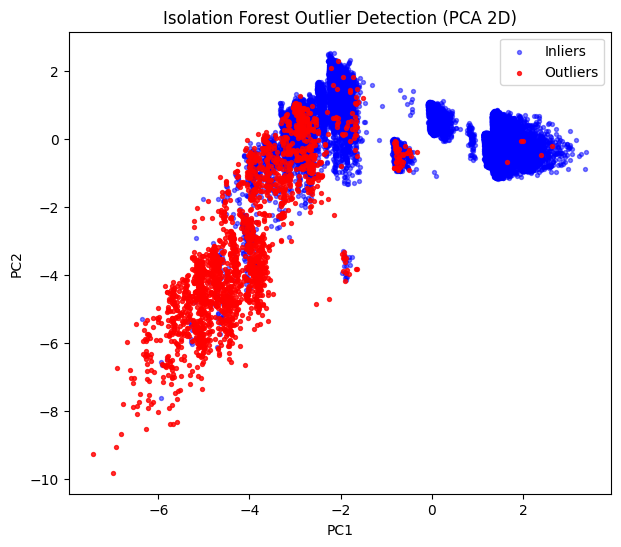

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_df)

plt.figure(figsize=(7,6))

plt.scatter(
    X_pca[labels == 1, 0], X_pca[labels == 1, 1],
    c="blue", s=8, alpha=0.5, label="Inliers"
)
plt.scatter(
    X_pca[labels == -1, 0], X_pca[labels == -1, 1],
    c="red", s=8, alpha=0.8, label="Outliers"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest Outlier Detection (PCA 2D)")
plt.legend()
plt.show()


## Analyze Outliers

In [15]:
tmp = pd.DataFrame({
    "is_outlier": (labels == -1).astype(int),  # 1 = outlier
    "y": y                                         # true target label (0 or 1)
})

pd.crosstab(tmp["is_outlier"], tmp["y"], normalize="index")


y,0,1
is_outlier,,
0,0.908045,0.091955
1,0.494175,0.505825


50% outliers represent customers who subscribed to the term deposit. So these outliers might be important information and not just noise. If we remove these outliers, we would remove most of the minority class and valuable rare behaviours. So we do not remove these outliers.